# Notebook 06 — Mouth Dataset Preparation




## 0. Mediapipe



In [1]:
import sys
import mediapipe as mp

print("Python:", sys.version)
print("Python executable:", sys.executable)
print("MediaPipe:", mp.__version__)


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Python executable: d:\driver-drowsiness-detection\venv\Scripts\python.exe
MediaPipe: 1.0.1


In [2]:
from pathlib import Path
import json
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

SEED = 42
IMG_SIZE = (224, 224)
MOUTH_CLASSES = ["no_yawn", "yawn"]

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

OUTPUT_DIR = PROJECT_ROOT / "outputs"
MOUTH_OUTPUT_DIR = PROJECT_ROOT / "mouth_dataset"
MODEL_DIR = PROJECT_ROOT / "models"
SPLIT_MANIFEST = OUTPUT_DIR / "dataset_split_manifest.csv"

for folder in [OUTPUT_DIR, MOUTH_OUTPUT_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Split manifest:", SPLIT_MANIFEST)


Project root: d:\driver-drowsiness-detection
Split manifest: d:\driver-drowsiness-detection\outputs\dataset_split_manifest.csv


## 1. Load the leakage-safe source manifest

In [3]:
if not SPLIT_MANIFEST.exists():
    raise FileNotFoundError(
        f"Missing {SPLIT_MANIFEST}. Run Notebook 02 first."
    )

df = pd.read_csv(SPLIT_MANIFEST)

required = {
    "filepath",
    "class",
    "split",
    "similarity_group_id"
}

missing = required - set(df.columns)

if missing:
    raise ValueError(
        f"Missing required columns: {sorted(missing)}"
    )

mouth_df = df[
    df["class"].isin(MOUTH_CLASSES)
].copy()

print("Mouth-task source images:", len(mouth_df))

print("\nClass distribution:")
print(mouth_df["class"].value_counts().sort_index())

print("\nSplit/class distribution:")
display(pd.crosstab(mouth_df["split"], mouth_df["class"]))


Mouth-task source images: 1448

Class distribution:
class
no_yawn    725
yawn       723
Name: count, dtype: int64

Split/class distribution:


class,no_yawn,yawn
split,,
test,118,103
train,500,504
validation,107,116


## 2. Verify similarity-group leakage

In [4]:
group_split_counts = (
    mouth_df.groupby("similarity_group_id")["split"].nunique()
)

leaking_groups = group_split_counts[group_split_counts > 1]

print("Groups appearing in multiple splits:", len(leaking_groups))

if len(leaking_groups):
    display(leaking_groups)
    raise AssertionError("Leakage detected in the mouth source dataset.")

print("✓ No similarity-group leakage.")


Groups appearing in multiple splits: 0
✓ No similarity-group leakage.


## 3. Download the MediaPipe Face Landmarker model


In [5]:
LANDMARK_MODEL_PATH = MODEL_DIR / "face_landmarker.task"

LANDMARK_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "face_landmarker/face_landmarker/float16/latest/"
    "face_landmarker.task"
)

if not LANDMARK_MODEL_PATH.exists():
    print("Downloading MediaPipe Face Landmarker model...")
    try:
        urllib.request.urlretrieve(
            LANDMARK_MODEL_URL,
            LANDMARK_MODEL_PATH
        )
        print("Download completed.")
    except Exception as e:
        raise RuntimeError(
            "Could not download the Face Landmarker model. "
            f"Place a compatible face_landmarker.task file at {LANDMARK_MODEL_PATH}"
        ) from e
else:
    print("Face Landmarker model already exists.")

print("Model:", LANDMARK_MODEL_PATH)


Download completed.
Model: d:\driver-drowsiness-detection\models\face_landmarker.task


## 4. Initialize MediaPipe Face Landmarker

In [6]:
base_options = python.BaseOptions(
    model_asset_path=str(LANDMARK_MODEL_PATH)
)

landmarker_options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.50,
    min_face_presence_confidence=0.50,
    min_tracking_confidence=0.50
)

face_landmarker = vision.FaceLandmarker.create_from_options(
    landmarker_options
)

print("✓ MediaPipe Face Landmarker initialized.")


✓ MediaPipe Face Landmarker initialized.


## 5. Define mouth landmarks




In [7]:
MOUTH_LANDMARKS = [
    61, 146, 91, 181, 84, 17, 314, 405, 321, 375,
    291, 409, 270, 269, 267, 0, 37, 39, 40, 185,
    95, 88, 178, 87, 14, 317, 402, 318, 324, 308
]

print("Number of mouth landmarks:", len(MOUTH_LANDMARKS))


Number of mouth landmarks: 30


## 6. Define landmark-based mouth extraction

In [8]:
def detect_mouth_landmarks(image_rgb):
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image_rgb
    )

    result = face_landmarker.detect(mp_image)

    if not result.face_landmarks:
        return None

    landmarks = result.face_landmarks[0]

    selected = []

    for index in MOUTH_LANDMARKS:
        if index < len(landmarks):
            point = landmarks[index]
            selected.append((point.x, point.y))

    if len(selected) < 10:
        return None

    return np.asarray(selected, dtype=np.float32)


def extract_mouth_region(image_rgb, normalized_landmarks):
    image_h, image_w = image_rgb.shape[:2]

    xs = normalized_landmarks[:, 0] * image_w
    ys = normalized_landmarks[:, 1] * image_h

    min_x = float(np.min(xs))
    max_x = float(np.max(xs))
    min_y = float(np.min(ys))
    max_y = float(np.max(ys))

    mouth_width = max_x - min_x
    mouth_height = max_y - min_y

    if mouth_width < 5 or mouth_height < 3:
        return None, None

    pad_x = max(8, 0.35 * mouth_width)
    pad_y = max(8, 0.60 * mouth_height)

    x1 = int(max(0, min_x - pad_x))
    y1 = int(max(0, min_y - pad_y))
    x2 = int(min(image_w, max_x + pad_x))
    y2 = int(min(image_h, max_y + pad_y))

    if x2 <= x1 or y2 <= y1:
        return None, None

    crop = image_rgb[y1:y2, x1:x2]

    if crop.size == 0:
        return None, None

    return crop, (x1, y1, x2, y2)


def prepare_mouth_image(source_path, destination_path):
    image_bgr = cv2.imread(str(source_path))

    if image_bgr is None:
        return None, "read_failed"

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    mouth_landmarks = detect_mouth_landmarks(image_rgb)

    if mouth_landmarks is None:
        return None, "mouth_landmarks_not_detected"

    mouth_crop, crop_box = extract_mouth_region(
        image_rgb,
        mouth_landmarks
    )

    if mouth_crop is None:
        return None, "mouth_crop_failed"

    resized = cv2.resize(
        mouth_crop,
        IMG_SIZE,
        interpolation=cv2.INTER_AREA
    )

    destination_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    Image.fromarray(resized).save(destination_path)

    return crop_box, "success"


print("✓ Landmark-based mouth extraction functions ready.")


✓ Landmark-based mouth extraction functions ready.


## 7. Create output folders

In [9]:
for split in ["train", "validation", "test"]:
    for cls in MOUTH_CLASSES:
        (MOUTH_OUTPUT_DIR / split / cls).mkdir(
            parents=True,
            exist_ok=True
        )

print("✓ Output folders ready.")


✓ Output folders ready.


## 8. Process the mouth dataset


In [10]:
records = []
start_time = time.time()

for _, row in mouth_df.reset_index(drop=True).iterrows():
    source_path = Path(row["filepath"])
    split = row["split"]
    cls = row["class"]

    destination_path = (
        MOUTH_OUTPUT_DIR / split / cls / source_path.name
    )

    crop_box, status = prepare_mouth_image(
        source_path,
        destination_path
    )

    records.append({
        "original_filepath": str(source_path),
        "prepared_filepath": (
            str(destination_path)
            if status == "success"
            else ""
        ),
        "class": cls,
        "split": split,
        "similarity_group_id": row["similarity_group_id"],
        "status": status,
        "crop_x1": crop_box[0] if crop_box else "",
        "crop_y1": crop_box[1] if crop_box else "",
        "crop_x2": crop_box[2] if crop_box else "",
        "crop_y2": crop_box[3] if crop_box else ""
    })

processing_seconds = time.time() - start_time
processing_df = pd.DataFrame(records)

print(
    f"Processing completed in "
    f"{processing_seconds / 60:.2f} minutes."
)

print("\nStatus:")
print(processing_df["status"].value_counts())

success_rate = processing_df["status"].eq("success").mean() * 100

print(f"\nSuccess rate: {success_rate:.2f}%")


Processing completed in 0.42 minutes.

Status:
status
success                         1429
mouth_landmarks_not_detected      19
Name: count, dtype: int64

Success rate: 98.69%


## 9. Review failed detections

In [11]:
failed_df = processing_df[
    processing_df["status"] != "success"
].copy()

print("Failed/uncertain records:", len(failed_df))

if len(failed_df):
    display(
        failed_df[
            [
                "original_filepath",
                "class",
                "split",
                "similarity_group_id",
                "status"
            ]
        ].head(30)
    )
else:
    print("✓ No preprocessing failures.")


Failed/uncertain records: 19


,original_filepath,class,split,similarity_group_id,status
50,D:\driver-drowsiness-detection\dataset\train\n...,no_yawn,train,SIM_0757,mouth_landmarks_not_detected
151,D:\driver-drowsiness-detection\dataset\train\n...,no_yawn,train,SIM_0825,mouth_landmarks_not_detected
152,D:\driver-drowsiness-detection\dataset\train\n...,no_yawn,train,SIM_0826,mouth_landmarks_not_detected
457,D:\driver-drowsiness-detection\dataset\train\n...,no_yawn,test,SIM_1060,mouth_landmarks_not_detected
703,D:\driver-drowsiness-detection\dataset\train\n...,no_yawn,train,SIM_1226,mouth_landmarks_not_detected
928,D:\driver-drowsiness-detection\dataset\train\y...,yawn,train,SIM_2100,mouth_landmarks_not_detected
982,D:\driver-drowsiness-detection\dataset\train\y...,yawn,train,SIM_2143,mouth_landmarks_not_detected
984,D:\driver-drowsiness-detection\dataset\train\y...,yawn,train,SIM_2143,mouth_landmarks_not_detected
987,D:\driver-drowsiness-detection\dataset\train\y...,yawn,test,SIM_2147,mouth_landmarks_not_detected
1005,D:\driver-drowsiness-detection\dataset\train\y...,yawn,test,SIM_2161,mouth_landmarks_not_detected


## 10. Create model-ready dataset

In [12]:
successful_df = processing_df[
    processing_df["status"] == "success"
].copy()

if successful_df.empty:
    raise ValueError("No successful mouth crops were generated.")

print("Model-ready mouth images:", len(successful_df))

print("\nClass distribution:")
print(successful_df["class"].value_counts().sort_index())

print("\nSplit/class distribution:")
display(pd.crosstab(successful_df["split"], successful_df["class"]))


Model-ready mouth images: 1429

Class distribution:
class
no_yawn    720
yawn       709
Name: count, dtype: int64

Split/class distribution:


class,no_yawn,yawn
split,,
test,117,97
train,496,497
validation,107,115


## 11. Validate generated crops

In [13]:
validation_errors = []

for _, row in successful_df.iterrows():
    path = Path(row["prepared_filepath"])

    if not path.exists():
        validation_errors.append((str(path), "missing"))
        continue

    try:
        with Image.open(path) as image:
            if image.size != IMG_SIZE:
                validation_errors.append(
                    (str(path), f"size={image.size}")
                )

            if image.mode != "RGB":
                validation_errors.append(
                    (str(path), f"mode={image.mode}")
                )

    except Exception as e:
        validation_errors.append((str(path), str(e)))

print("Validation errors:", len(validation_errors))

if validation_errors:
    display(
        pd.DataFrame(
            validation_errors,
            columns=["filepath", "error"]
        ).head(20)
    )
    raise AssertionError(
        "Generated mouth dataset validation failed."
    )

print("✓ All generated crops are 224×224 RGB.")


Validation errors: 0
✓ All generated crops are 224×224 RGB.


## 12. Visual quality check


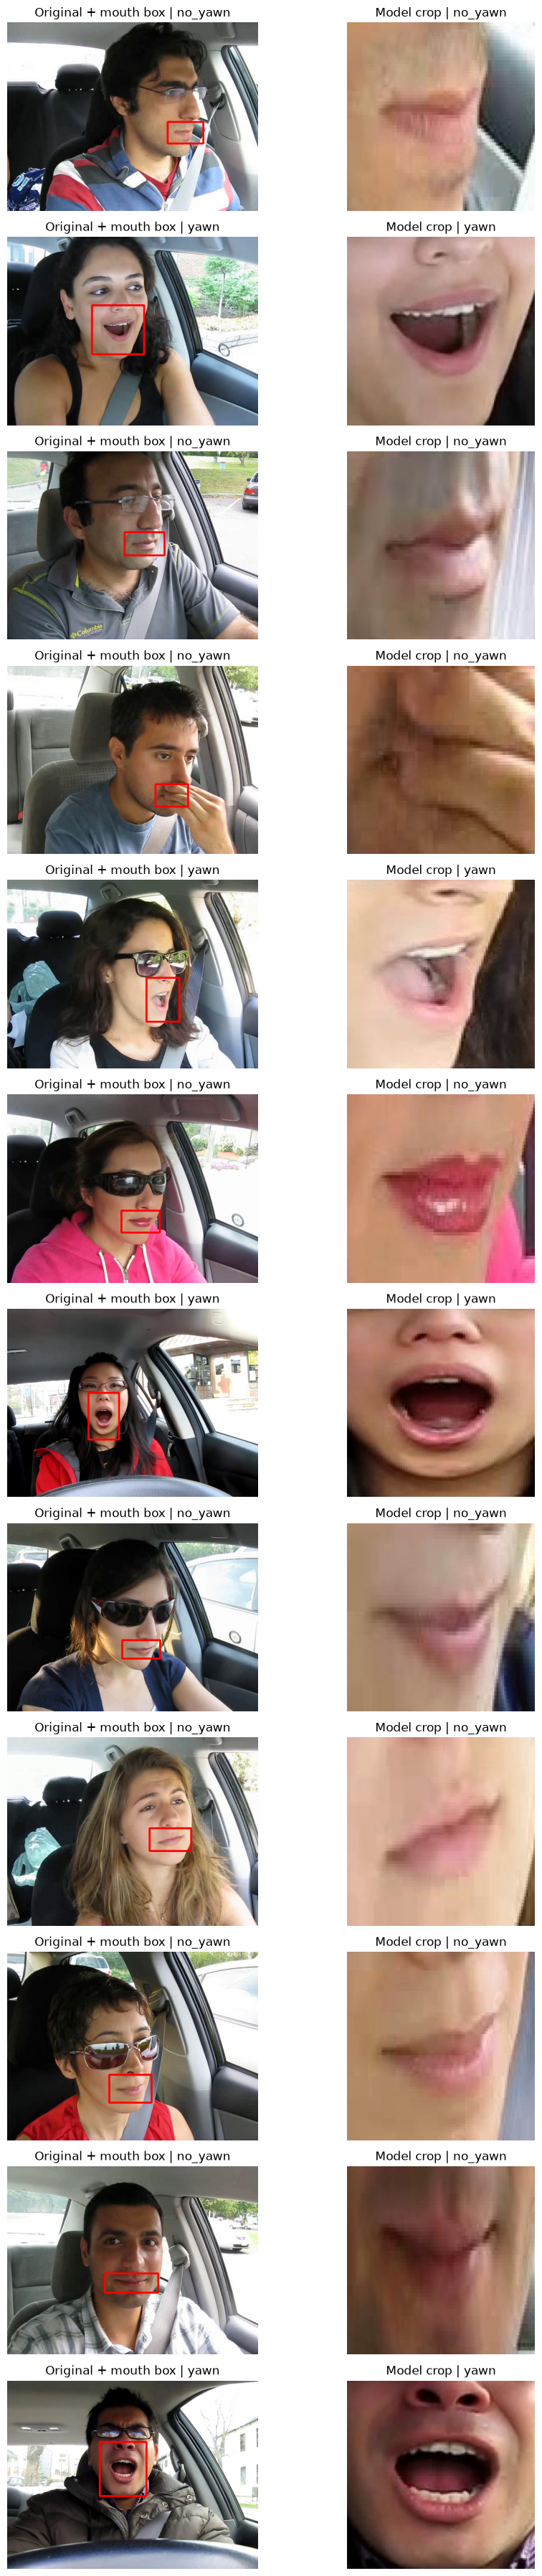

Saved: d:\driver-drowsiness-detection\outputs\mouth_landmark_quality_sample.png


In [14]:
sample_n = min(12, len(successful_df))

sample_df = successful_df.sample(
    n=sample_n,
    random_state=SEED
).reset_index(drop=True)

fig, axes = plt.subplots(
    sample_n,
    2,
    figsize=(10, 3 * sample_n)
)

if sample_n == 1:
    axes = np.asarray([axes])

for i, row in sample_df.iterrows():
    source_path = Path(row["original_filepath"])
    prepared_path = Path(row["prepared_filepath"])

    original_bgr = cv2.imread(str(source_path))

    if original_bgr is None:
        axes[i, 0].set_title("Source image unavailable")
        axes[i, 0].axis("off")
        axes[i, 1].axis("off")
        continue

    original_rgb = cv2.cvtColor(
        original_bgr,
        cv2.COLOR_BGR2RGB
    )

    x1 = int(row["crop_x1"])
    y1 = int(row["crop_y1"])
    x2 = int(row["crop_x2"])
    y2 = int(row["crop_y2"])

    boxed = original_rgb.copy()

    cv2.rectangle(
        boxed,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        3
    )

    crop = Image.open(prepared_path)

    axes[i, 0].imshow(boxed)
    axes[i, 0].set_title(
        f"Original + mouth box | {row['class']}"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(crop)
    axes[i, 1].set_title(
        f"Model crop | {row['class']}"
    )
    axes[i, 1].axis("off")

plt.tight_layout()

quality_path = (
    OUTPUT_DIR /
    "mouth_landmark_quality_sample.png"
)

plt.savefig(
    quality_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", quality_path)


## 13. Verify similarity-group leakage after preprocessing

In [15]:
prepared_group_splits = (
    successful_df
    .groupby("similarity_group_id")["split"]
    .nunique()
)

prepared_leaks = prepared_group_splits[
    prepared_group_splits > 1
]

print(
    "Prepared groups appearing in multiple splits:",
    len(prepared_leaks)
)

if len(prepared_leaks):
    display(prepared_leaks)
    raise AssertionError(
        "Leakage detected after preprocessing."
    )

print("✓ Prepared mouth dataset remains leakage-safe.")


Prepared groups appearing in multiple splits: 0
✓ Prepared mouth dataset remains leakage-safe.


## 14. Save manifests

In [16]:
all_manifest_path = (
    OUTPUT_DIR /
    "mouth_preprocessing_landmark_manifest.csv"
)

model_manifest_path = (
    OUTPUT_DIR /
    "mouth_dataset_landmark_manifest.csv"
)

processing_df.to_csv(
    all_manifest_path,
    index=False
)

successful_df.to_csv(
    model_manifest_path,
    index=False
)

print("Saved:")
print(all_manifest_path)
print(model_manifest_path)


Saved:
d:\driver-drowsiness-detection\outputs\mouth_preprocessing_landmark_manifest.csv
d:\driver-drowsiness-detection\outputs\mouth_dataset_landmark_manifest.csv


## 15. Save summary

In [17]:
summary = {
    "task": "Mouth State Classification",
    "preprocessing_method": "MediaPipe Face Landmarks",
    "classes": MOUTH_CLASSES,
    "source_images": int(len(mouth_df)),
    "successful_mouth_crops": int(len(successful_df)),
    "failed_or_uncertain": int(len(failed_df)),
    "success_rate_percent": round(
        float(success_rate),
        2
    ),
    "image_size": list(IMG_SIZE),
    "similarity_group_leaks": int(len(prepared_leaks)),
    "processing_minutes": round(
        processing_seconds / 60,
        3
    )
}

summary_path = (
    OUTPUT_DIR /
    "mouth_landmark_dataset_summary.json"
)

summary_path.write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8"
)

print(json.dumps(summary, indent=2))
print("\nSaved:", summary_path)


{
  "task": "Mouth State Classification",
  "preprocessing_method": "MediaPipe Face Landmarks",
  "classes": [
    "no_yawn",
    "yawn"
  ],
  "source_images": 1448,
  "successful_mouth_crops": 1429,
  "failed_or_uncertain": 19,
  "success_rate_percent": 98.69,
  "image_size": [
    224,
    224
  ],
  "similarity_group_leaks": 0,
  "processing_minutes": 0.422
}

Saved: d:\driver-drowsiness-detection\outputs\mouth_landmark_dataset_summary.json
